# Bootcamp 8: Practice with Pandas (Solution)

This notebook is meant as a review of some of the more salient features of Pandas. To be clear, we will not be focusing on *reading in data*; rather, this notebook will focus more on using Pandas for selecting and analyzing data (using Pandas, of course). 

We’ll be using a data set of weather data from various weather stations around the US (`weather.csv`) over time. We are going to be exploring the average temperature in a few different states in different years.

## Part 0: Importing Packages and Reading in the Data

As a first step, let’s import the necessary packages and read in the data. Then, we'll use .head() to take a first look at the data.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

weather_data = pd.read_csv('weather.csv')
weather_data.head()

,Date_Month,Date_Year,Station_City,Station_State,Data_Temperature,Data_Precipitation
0,1,2016,Birmingham,Alabama,39,0.00
1,1,2016,Huntsville,Alabama,39,0.00
2,1,2016,Mobile,Alabama,46,0.16
3,1,2016,Montgomery,Alabama,45,0.00
4,1,2016,Anchorage,Alaska,34,0.01


**NOTE:** Sometimes, when you have a data file you are having trouble figuring out the column headers, you can use the pandas function `.keys()` to tell you the exact strings!

In [6]:
weather_data.keys()

Index(['Date_Month', 'Date_Year', 'Station_City', 'Station_State',
       'Data_Temperature', 'Data_Precipitation'],
      dtype='object')

## Part 1: Analyzing a Single State

#### 1.0 Filtering down to one year

You may have noticed that the dataframe contains weather station data from both 2016 and 2017, let's start by masking our dataframe to just include data from 2016.

In [13]:
# Filter the data with a mask

year_mask = weather_data['Date_Year']==2016
year_data = weather_data[year_mask]
year_data

,Date_Month,Date_Year,Station_City,Station_State,Data_Temperature,Data_Precipitation
0,1,2016,Birmingham,Alabama,39,0.00
1,1,2016,Huntsville,Alabama,39,0.00
2,1,2016,Mobile,Alabama,46,0.16
3,1,2016,Montgomery,Alabama,45,0.00
4,1,2016,Anchorage,Alaska,34,0.01
...,...,...,...,...,...,...
16421,12,2016,Casper,Wyoming,27,0.39
16422,12,2016,Cheyenne,Wyoming,34,0.04
16423,12,2016,Lander,Wyoming,19,0.33
16424,12,2016,Rawlins,Wyoming,27,0.36


#### 1.1
&#9989;&nbsp; **Pick a single state (from the column name `Station State`). Create a new dataframe that just contains that state**

In [ ]:
# Write your code here

In [15]:
###ANSWER###
FL_mask = year_data['Station_State'] == "Florida"
florida_data = year_data[FL_mask]
florida_data.describe()

,Date_Month,Date_Year,Data_Temperature,Data_Precipitation
count,624.000000,624.0,624.000000,624.000000
mean,6.442308,2016.0,74.059295,0.904119
std,3.446897,0.0,9.541563,1.363191
min,1.000000,2016.0,44.000000,0.000000
25%,3.750000,2016.0,68.000000,0.030000
50%,6.500000,2016.0,76.000000,0.400000
75%,9.250000,2016.0,82.000000,1.232500
max,12.000000,2016.0,87.000000,15.190000


#### 1.2

Our ultimate goal is to see what the average temperature is for each month in our state's data. Using another mask, select one month from the `Date_Month` column. Then calculate the average temperature of the `Data_Temperature` column for that month.

In [ ]:
# Write your code here

In [19]:
###ANSWER###

month_mask = florida_data["Date_Month"] == 1
month_data = florida_data[month_mask]
month_data.describe() # or month_data["Data_Temperature"].mean()

,Date_Month,Date_Year,Data_Temperature,Data_Precipitation
count,60.0,60.0,60.000000,60.000000
mean,1.0,2016.0,59.950000,1.171000
std,0.0,0.0,8.434041,1.045788
min,1.0,2016.0,44.000000,0.050000
25%,1.0,2016.0,54.000000,0.460000
50%,1.0,2016.0,60.000000,0.925000
75%,1.0,2016.0,66.250000,1.615000
max,1.0,2016.0,79.000000,5.530000


#### 1.3

&#9989;&nbsp; **Now repeat the process above (for your state), but for the other 11 months.** You can do this by making a new mask and new masked dataframe for each month, but try to do it in as compact a way as possible! Using a loop or a function would be a good way to approach it!

In [ ]:
# Write your code here

In [25]:
###ANSWER###

all_months_mean = []
for month in range(1,13):
    df_temp = florida_data[florida_data['Date_Month'] == month]
    all_months_mean.append(df_temp['Data_Temperature'].mean())
print(all_months_mean)

[59.95, 61.5625, 69.85416666666667, 71.95833333333333, 77.45, 82.33333333333333, 84.4, 83.79166666666667, 82.25, 77.03333333333333, 68.8125, 68.66666666666667]


#### 1.4

&#9989;&nbsp; **Create a plot that visualizes the monthly average temperature for your state. Make sure to include all of the appropriate details in your plot!**

In [33]:
# put your answer here

Text(0, 0.5, 'temperature')

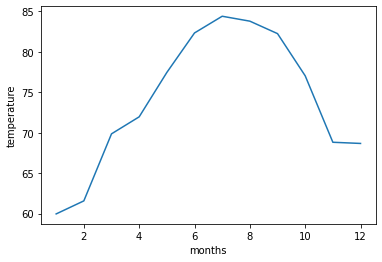

In [26]:
### ANSWER
import matplotlib.pyplot as plt

plt.plot(range(1,13),all_months_mean)
plt.xlabel('months')
plt.ylabel('temperature')

#### 1.5

&#9989;&nbsp; **What do you notice about the average temperature across the months? Does it make sense to you, given the climate of the state you chose?**

*PUT YOUR ANSWER HERE*

### ANSWER ###
In general, the temperature hsould peak in the summer months and be lower in the winter months. More temperate states will have higher average temperatures than more northern states.

### 2.0 Challenge Problem

&#9989;&nbsp; Now, we want to expand the above procedure to additional states. Bringing together all of your knowledge of loops, functions, pandas, and matplotlib, repeat the above process for one state for several other states. Try to do it using loops and/or functions to make your code compact and easier to debug! This is more challenging than what hsould be on a quiz but will let you practice alot of what you have learned up to this point!

In [ ]:
# Write your code here

Text(0, 0.5, 'temperature')

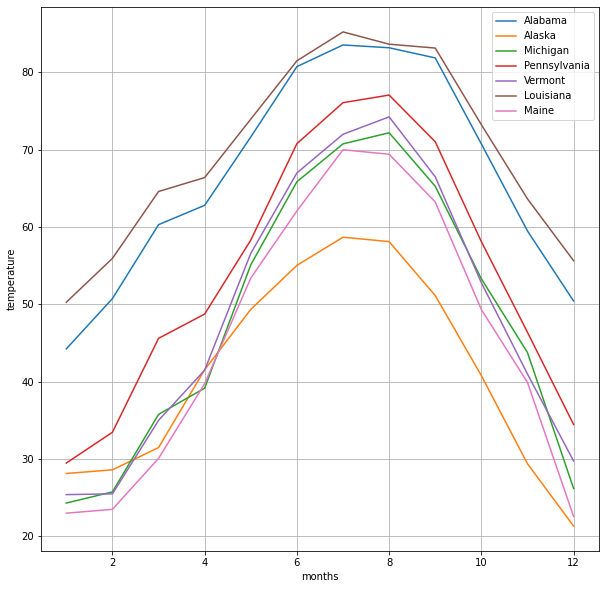

In [32]:
###ANSWER###
# Solution done by combining code from above, could also write functions that do these things and run the function for any state
plt.figure(figsize=(10,10))
states = ['Alabama','Alaska','Michigan','Pennsylvania','Vermont','Louisiana','Maine']

for state_name in states:
    state_mask = year_data['Station_State'] == state_name
    state_data = year_data[state_mask]
    all_months_mean = []
    for month in range(1,13):
        df_temp = state_data[state_data['Date_Month'] == month]
        all_months_mean.append(df_temp['Data_Temperature'].mean())
    plt.plot(range(1,13),all_months_mean,label=state_name)
    plt.legend()
    plt.grid()
plt.xlabel('months')
plt.ylabel('temperature')